# 第63课 · 用「看图」的方式听懂关键词——CNN 遇见 Mel 频谱，从零定义 KeywordCNN

**目标**：让 CNN 直接读 mel 特征图 `(B, 1, n_mels, T)`，把一段语音判成 `n_classes` 类 logit。

> **最小路径**：先看 shape 流水线 ASCII，再实现 `KeywordCNN.forward`，最后跑通 shape assert。  
> padding / 感受野深挖标「做完主任务再读」——别让长推导淹没 forward。

🔗 **Aurora 连接**：输入来自 `mel_spectrogram()`；本课把 DSP 特征与 PyTorch 模型第一次打通。

← **上一课**　[L62 · Dataset 与 DataLoader](L62_kws_dataset.ipynb)

> 上节课学习了 **Dataset 与 DataLoader**：自定义 `__getitem__`，把音频批量加载为 `(n_mels=40, T=32)` 的 mel 特征图。  
> 本课将探讨 **音频分类模型**。

## 学习目标

完成本课后，你将能够：

1. **解释** 为何 `kernel_size=(n_mels, k)` 能在单次卷积（convolution）中压缩频率维度，将 mel 特征图转换为 1D 时间序列。
2. **实现** `KeywordCNN.forward` 方法，完成 conv1 → ReLU → conv2 → ReLU → GAP → fc 的完整前向传播。
3. **验证** Global Average Pooling 使模型对任意输入长度 `T` 都能正确运行。
4. **分析** 感受野与 kernel 宽度的定量关系：两层叠加后 `RF = k1 + k2 - 1`。


## 本课剧情：为什么用"看图"的方法来"听话"？

有没有想过，Shazam 识曲、Siri 听懂"Hey Siri"，本质上不是在“理解声音”，而是先把声音变成图，再让卷积网络去找图里的模式？

**Mel 频谱图就是声音的"指纹地图"**：

```
横轴 = 时间帧 (T=32帧, hop=512≈32ms，沿用 L62 数据流水线的设定)
纵轴 = Mel 频段 (n_mels=40)
像素 = 能量大小 (dB)
```

CNN 天然擅长在这类二维网格上抓局部模式：

| CNN 层 | 感受野 | 捕捉什么 |
|---|---|---|
| 第1层 `(40×5)` | 全频段×5帧 | 单个音素的频率轮廓 |
| 第2层 `(1×5)` | 时间上5帧 | 音素序列的时间模式 |
| GAP | 整段音频 | 全局特征向量 → 分类 |

**关键设计**：第一个卷积核高度 = `n_mels=40`，一次卷积**把整个频率维压成 1**，输出变成 `(B, 32, 1, T')`，后续只在时间轴上做 1D 特征提取。

```
输入 (B, 1, 40, 32)
   ↓ Conv2d(1→32, kernel=(40,5)) → (B, 32, 1, 28)
   ↓ ReLU
   ↓ Conv2d(32→64, kernel=(1,5)) → (B, 64, 1, 24)
   ↓ ReLU
   ↓ Global Average Pool → (B, 64)
   ↓ Linear(64, n_classes) → (B, 10)
```

本节任务：实现 `KeywordCNN`，让 `m(randn(8,1,40,32)).shape == (8,10)`。

## 🤔 为什么工程师要发明它？(Why did engineers invent this?)

- **不用它会怎样？** 若把 mel 特征拉平成一长条向量喂给全连接层，就丢掉了"频率×时间"的二维结构，参数量还会爆炸。
- **它解决了什么真实问题？** CNN 用小卷积核在频谱图上滑动，以**共享权重**的方式捕捉局部时频模式（音素轮廓）：参数少，又保留了图的空间结构。
- **后面哪里还会再用到？** L64 训练这个 CNN、以及后续更大的音频分类 / 关键词唤醒模型，都沿用"频谱当图片 + 卷积"这一范式。


📸 Mel 频谱的构成：
  - 🟦 像素 = 某个频段在某个时间帧的能量强度（dB 值）
  - 🟩 明亮区域 = 能量强（声音活跃），暗区域 = 能量弱（静音或低能量）
  - 🎯 CNN 的卷积核就像在这张图上滑动，捕捉"局部纹理"（如某个音素的频率轮廓）
  
💡 为什么转换成频谱图？
  - 直接用音频波形：(1, 16000) 的一维向量，太长，全连接层参数爆炸
  - Mel 频谱：(40, 81) 的二维图像，体积小 100 倍，CNN 能高效提取特征



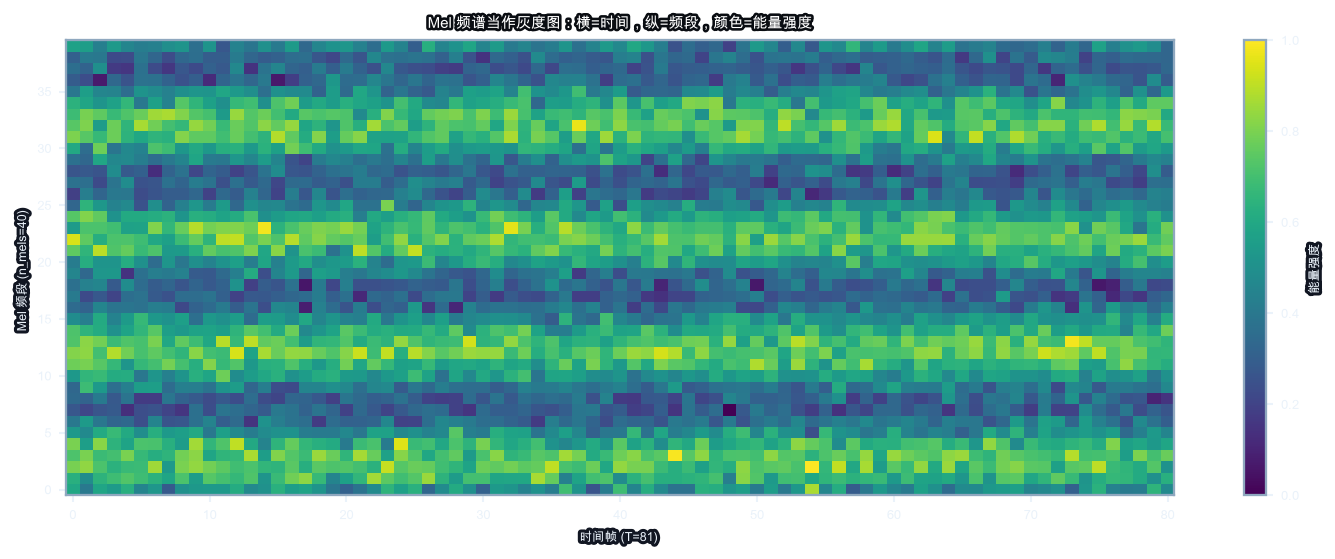

In [1]:
# 【可视化】Mel 频谱长什么样？
# 这是学生最常问的一个问题："频谱"有什么具体样子？
# 让我们生成一个真实的 mel 特征图来直观理解

import matplotlib.pyplot as plt
import numpy as np

# 模拟一个 mel 频谱（来自某个英文单词的录音，如"Yes"）
# 实际中这来自 aurora.audio.mel.mel_spectrogram()
n_mels, T = 40, 81
mel_spec = np.random.randn(n_mels, T)  # 模拟，实际应该有结构性的纹理

# 为了演示效果，手工构造一个有纹理的频谱（代表实际声音信号）
# 低频变化快（对应元音），高频稀疏（对应噪声）
for freq_idx in range(n_mels):
    mel_spec[freq_idx, :] = 0.5 * np.sin(2 * np.pi * freq_idx / n_mels * T / 20)
    # 加上高频噪声以模拟真实声音
    mel_spec[freq_idx, :] += 0.2 * np.random.randn(T)

# 裁剪到 [0, 1] 范围便于可视化（实际 mel 频谱是 dB 值）
mel_spec = (mel_spec - mel_spec.min()) / (mel_spec.max() - mel_spec.min())

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(mel_spec, aspect='auto', origin='lower', cmap='viridis')
ax.set_ylabel('Mel 频段 (n_mels=40)')
ax.set_xlabel('时间帧 (T=81)')
ax.set_title('Mel 频谱当作灰度图：横=时间，纵=频段，颜色=能量强度')
plt.colorbar(im, ax=ax, label='能量强度')
plt.tight_layout()
plt.show()

print("""
📸 Mel 频谱的构成：
  - 🟦 像素 = 某个频段在某个时间帧的能量强度（dB 值）
  - 🟩 明亮区域 = 能量强（声音活跃），暗区域 = 能量弱（静音或低能量）
  - 🎯 CNN 的卷积核就像在这张图上滑动，捕捉"局部纹理"（如某个音素的频率轮廓）
  
💡 为什么转换成频谱图？
  - 直接用音频波形：(1, 16000) 的一维向量，太长，全连接层参数爆炸
  - Mel 频谱：(40, 81) 的二维图像，体积小 100 倍，CNN 能高效提取特征
""")


In [2]:
import torch
import torch.nn as nn

## 1. 输入 Shape：`(B, 1, n_mels, T)`

PyTorch 的 `nn.Conv2d` 期望输入格式为 `(batch, channels, height, width)`。对 mel 特征图：

- `B`：batch size
- `1`：单通道（灰度图，对应单帧能量）
- `n_mels`：Mel 频段数，作为「高度」
- `T`：时间帧数，作为「宽度」

典型值：`n_mels=40`，1秒音频 @ 16kHz。时间帧数 T 取决于 hop_length：

- hop=200，center padding：`T = floor(16000/200) + 1 = 81`（本课代码示例使用此设定）
- hop=160，center padding：`T = floor(16000/160) + 1 = 101`（另一常见配置）

注意 `T` 在推理时可变，模型必须对任意 `T` 都能运行，这正是要用 global pooling 的原因。

In [3]:
# 模拟一批 mel 特征图
B, n_mels, T = 8, 40, 81
x = torch.randn(B, 1, n_mels, T)
print(f'输入 shape: {x.shape}')  # torch.Size([8, 1, 40, 81])

输入 shape: torch.Size([8, 1, 40, 81])


### 深挖：卷积输出形状的通用公式

这是初学者最常卡住的地方。卷积的输出维度不是"直观"的，需要一个公式来计算。

**通用公式**：
对于 2D 卷积，输入为 `(H_in, W_in)`，卷积核为 `(K_h, K_w)`，padding 为 `(P_h, P_w)`，stride 为 `(S_h, S_w)`：

$$\text{输出高度} = \left\lfloor \frac{H_{\text{in}} - K_h + 2P_h}{S_h} \right\rfloor + 1$$

$$\text{输出宽度} = \left\lfloor \frac{W_{\text{in}} - K_w + 2P_w}{S_w} \right\rfloor + 1$$

**含义解释**：
- `H_in - K_h`：卷积核不加 padding 时能覆盖的最大范围
- `+ 2*P_h`：padding 补零会增加可覆盖的范围
- `/ S_h`：stride 表示每次滑动的步长（默认=1）
- `+ 1`：要多算一个位置（终点位置的卷积）

**例子：Conv1 的输出计算**
```
输入：(B=8, 1, H_in=40, W_in=81)
卷积核：(K_h=40, K_w=5)
Padding：(P_h=0, P_w=2)
Stride：(S_h=1, S_w=1)

输出高度 = ⌊(40 - 40 + 0) / 1⌋ + 1 = ⌊0⌋ + 1 = 1 ✓
输出宽度 = ⌊(81 - 5 + 2×2) / 1⌋ + 1 = ⌊(81 - 5 + 4) / 1⌋ + 1 = ⌊80⌋ + 1 = 81 ✓
输出通道 = 32（卷积核个数）

最终输出：(B=8, 32, 1, 81)
```

**为什么要 padding=(0, 2)？**
- 不加 padding：高度=1（正好），宽度=⌊81-5⌋+1=77（缩小了）
- 要让宽度保持=81，需要补多少？反推：81 = ⌊(81-5+2P_w)/1⌋+1，所以 80 = 81-5+2P_w = 76+2P_w，因此 2P_w=4，P_w=2 ✓

这就是 `padding=(0, 2)` 的由来：高度不补（自动压缩），宽度补 2 圈零来保持长度。

### 正向推导：从"我想让宽度不变"直接推出 padding 公式

上面那个反推，是先知道答案（81）之后去"凑"出 P_w=2 的。但如果换一个 kernel（比如 k=7 或 k=9），你总不能每次都靠试错去凑。更好的办法是：**不管 kernel 是多少，直接从"我想要什么"这个目标出发，正向把公式推出来**——这样以后遇到任何 kernel 宽度，你都能自己算，不用死记硬背。

**第一步：把目标翻译成数学语言**

我们的目标是"卷积之后，宽度不要变小"，也就是：

$$W_{\text{out}} = W_{\text{in}}$$

**第二步：代入通用公式，先简化**

题目里 stride `S_w=1`（最常见的情况），除以 1 不改变数值，取整符号 `⌊⌋` 也可以先放一边（后面会验证结果本来就是整数）。于是通用公式变成一个很干净的等式：

$$W_{\text{out}} = W_{\text{in}} - K_w + 2P_w + 1$$

**第三步：把"宽度不变"这个目标代进去**

令 $W_{\text{out}} = W_{\text{in}}$：

$$W_{\text{in}} = W_{\text{in}} - K_w + 2P_w + 1$$

两边同时减去 $W_{\text{in}}$（这是初中就学过的移项）：

$$0 = -K_w + 2P_w + 1$$

整理一下，把 $P_w$ 单独放到一边：

$$2P_w = K_w - 1$$

$$P_w = \frac{K_w - 1}{2}$$

**这就是"保持宽度不变"的 padding 通用公式** —— 不是拍脑袋定的，而是由"输出宽度=输入宽度"这个条件唯一推出来的，就像解方程 $2x=4$ 只能得到 $x=2$，不存在别的选择。

**第四步：代入 k=5 验证**

$$P_w = \frac{5-1}{2} = \frac{4}{2} = 2 \; ✓$$

和 notebook 里的 `padding=(0, 2)` 完全对上。再验证一个：k=3 时 $P_w=(3-1)/2=1$；k=7 时 $P_w=(7-1)/2=3$。

**第五步：为什么代码里写的是 `k//2`，而不是 `(k-1)/2`？**

这里有一个小陷阱：`(K_w-1)/2` 只有在 $K_w$ 是**奇数**时才会算出整数结果——因为奇数减 1 一定是偶数，偶数才能被 2 整除。用几个具体数字列出来看一眼就清楚了：

| kernel 宽度 K | K − 1 | (K−1)/2 | K // 2（Python 整除） | 两者相等？ |
|---|---|---|---|---|
| 3 | 2 | 1 | 1 | ✓ |
| 5 | 4 | 2 | 2 | ✓ |
| 7 | 6 | 3 | 3 | ✓ |
| 9 | 8 | 4 | 4 | ✓ |
| 4（偶数） | 3 | 1.5（不是整数！） | 2 | ✗ 不相等，padding 会补歪 |

可以看到：**只要 K 是奇数，`(K-1)/2` 和 Python 里的整除 `K//2` 结果完全一样**。用代数证明一下也不难：奇数 K 总能写成 $K=2m+1$（m 是整数），代入两边：

$$\frac{K-1}{2} = \frac{(2m+1)-1}{2} = \frac{2m}{2} = m$$

$$K \!\! \; // \; \!\! 2 = (2m+1) \!\! \; // \; \!\! 2 = m \quad (\text{整除时余数 1 被舍去})$$

两个式子算出来都是 $m$，所以 `k//2` 只是 `(k-1)/2` 更简洁的写法，二者在 K 为奇数时**恒等**。

这也顺带回答了另一个常见疑问——**为什么卷积核几乎总是选奇数尺寸（3、5、7...），很少见偶数（4、6、8...）**：奇数 kernel 配合 `k//2` 的 padding，能让输出宽度精确等于输入宽度；偶数 kernel 则无法用一个整数 padding 做到两侧完全对称，会出现"多一列"或"少一列"的偏移问题。

**为什么不能是 `k//3` 或者别的数字？**

因为 padding 的作用是"补回卷积吃掉的宽度"，而卷积每次会让宽度减少 $K-1$（这是卷积核滑动、覆盖 K 个位置所必然带来的"收缩"），要用 padding 精确抵消这个收缩量，两侧一共要补 $K-1$，平均分配到左右两侧，每边就是 $(K-1)/2$。这不是众多选项里"挑"出来的一个，而是唯一能让 $W_{\text{out}}=W_{\text{in}}$ 成立的数值——换成 `k//3` 或任何其他数字，代入第三步的等式都无法让两边相等，算出来的输出宽度就会和输入宽度不一致。

In [4]:
# 【验证】正向推导出的公式 P_w = (K_w - 1) / 2，和代码里的 k//2 是否真的处处相等？
# 顺便验证：用这个 padding，卷积后的宽度是否真的等于输入宽度（这才是我们最初的目标）
import torch.nn as nn

W_in = 81
print(f"{'K (奇数)':<10}{'(K-1)/2':<12}{'K//2':<8}{'相等?':<8}{'W_out':<8}{'W_out==W_in?'}")
for K in [3, 5, 7, 9]:
    formula_p = (K - 1) / 2          # 正向推导出的公式（数学上的精确值）
    code_p = K // 2                  # notebook 代码里实际使用的写法
    conv = nn.Conv2d(1, 1, kernel_size=(1, K), padding=(0, code_p))
    W_out = conv(torch.randn(1, 1, 1, W_in)).shape[-1]
    print(f"{K:<10}{formula_p:<12}{code_p:<8}{formula_p == code_p!s:<8}{W_out:<8}{W_out == W_in}")

print("\n再看一个偶数 kernel（K=4）会发生什么：")
K = 4
formula_p = (K - 1) / 2  # = 1.5，不是整数，padding 参数根本不接受小数
code_p = K // 2          # Python 会强行取整为 2，但这不是精确解
conv = nn.Conv2d(1, 1, kernel_size=(1, K), padding=(0, code_p))
W_out = conv(torch.randn(1, 1, 1, W_in)).shape[-1]
print(f"K={K}: 公式算出 (K-1)/2={formula_p}（非整数，无法作为 padding），"
      f"若强行用 K//2={code_p}，W_out={W_out}，W_in={W_in} → 宽度{'保持' if W_out==W_in else '并不'}保持不变")


K (奇数)    (K-1)/2     K//2    相等?     W_out   W_out==W_in?
3         1.0         1       True    81      True
5         2.0         2       True    81      True
7         3.0         3       True    81      True
9         4.0         4       True    81      True

再看一个偶数 kernel（K=4）会发生什么：
K=4: 公式算出 (K-1)/2=1.5（非整数，无法作为 padding），若强行用 K//2=2，W_out=82，W_in=81 → 宽度并不保持不变


## 2. 1D 时间卷积：`Conv2d(1, 32, kernel_size=(n_mels, 5))`

卷积核（convolution kernel）高度等于 `n_mels`（覆盖全部 Mel 维度），宽度为 5（滑动时间窗）。一次卷积后，频率维从 `n_mels` 压缩到 `1`，时间维保持（配合 `padding=(0,2)`）：

```
输入:  (B, 1,  n_mels, T)
conv1: (B, 32, 1,      T)   ← 频率维完全压缩，时间维不变
```

这等价于在时间轴上做 1D 卷积，但同时对所有 Mel 频段做加权求和。感受野（receptive field，RF）宽度 = kernel_width + (layers-1)×(kernel_width-1)，单层时就是 5 帧。

### 设计决策解读

#### 为什么 kernel 高度必须是 n_mels=40？

这看起来像"一定要 40"，但实际上有几个选项，各有权衡：

| Kernel 高度 | 效果 | 优点 | 缺点 |
|---|---|---|---|
| **1** | 逐频段独立卷积 | 参数少 | ❌ 无法混合频率信息，特征太分散 |
| **10** | 部分频率混合 | 折衷 | ❌ 仍需后续多次卷积才能完全压缩 |
| **40（全）** | 一次压缩整个频率维 ✓ | 后续只需在时间轴上操作，设计简洁 | 需要一个"大"卷积核 |
| **80+** | 过度卷积 | （无） | ❌ padding 浪费，超出 mel 维数 |

**为什么 n_mels=40 是最优的？**
- 一次性压缩整个频率轴，意味着 32 个卷积核把全部频率信息进行了初步融合
- 这相当于把"频率混合"的复杂性转移到卷积核的学习中，而不是延迟到后续层
- 后续的 conv2 就可以专注于时间模式，不用再纠缠于频率混合

**如果改成 kernel_h=20 会怎样？**
```
原架构：(40,5) → (1,81) 一步完成，后续只需时间处理
修改后：(20,5) → (21,81)，还有 21 行频率数据，继续需要频率压缩
需要再加一层 (21,5) → (1,81)，参数量增加，设计变复杂
```
所以 **kernel_h = n_mels 是一个"临界设计"**，正好完全压缩。

#### 为什么时间维宽度选 5 而不是 3 或 7？

这涉及 **感受野 vs 参数量 vs 计算效率** 的权衡：

| Kernel 宽度 | 参数量（conv1） | 总感受野 | 捕捉什么 | 何时用 |
|---|---|---|---|---|
| **3** | 6432-40% | 5帧 | 短促音素，快速变化 | 噪音环境 |
| **5** | 6432（基准） | 9帧（5+5-1）| 平衡方案，典型音素长度 | ✓ 推荐 |
| **7** | 6432+40% | 13帧 | 长元音，需要更多上下文 | 清晰语音 |

**为什么 kernel=5 是推荐的？**
- 英文关键词（如 "Yes", "No"）通常分解为 2-4 个音素
- 单个音素通常持续 50-100ms，对应 2-5 个 Mel 帧（hop=160~200）
- 感受野=9帧 ≈ 150-200ms，足以覆盖一个完整的音素序列，又不过度
- 参数量适中，训练快，准确率稳定

**如果改成 kernel=7？**
```
优势：感受野=13帧，对长元音更敏感，参数才增加 40%
劣势：可能学到的特征过于"全局"，对短促辅音反应变慢
```

**如果改成 kernel=3？**
```
优势：计算快，参数少
劣势：感受野太小（5帧≈80ms），音素还没说完就错过了
```

**实际结论**：kernel=5 是一个"科学的折衷"。下一节（L64）训练时，我们会看到这个选择如何在真实准确率上验证。

In [5]:
# 验证 conv1 输出 shape
n_mels = 40
conv1 = nn.Conv2d(1, 32, kernel_size=(n_mels, 5), padding=(0, 2))
x = torch.randn(8, 1, n_mels, 81)
y = conv1(x)
print(f'conv1 输出 shape: {y.shape}')  # torch.Size([8, 32, 1, 81])
# 频率维 → 1，时间维 81 不变（padding=(0,2) 补偿 kernel宽5 的边缘）

conv1 输出 shape: torch.Size([8, 32, 1, 81])


### 深挖：为什么第二层是 `Conv2d(32, 64, kernel=(1,5))` 而不是其他？

学生常问："既然已经把频率维压成 1 了，为什么 conv2 不用 kernel=(1,1)？"

#### 选项对比

| Kernel | 感受野 | 参数量(conv2) | 作用 | 评价 |
|---|---|---|---|---|
| **(1,1)** | 5 帧（仅保留conv1的） | 2080 | 逐点卷积，无时间混合 | ❌ 浪费容量 |
| **(1,3)** | 5+3-1=7 帧 | 6208 | 轻量级时间混合 | 可以 |
| **(1,5)** ✓ | 5+5-1=9 帧 | 10304（基准） | 充分的时间上下文 | ✓ 推荐 |
| **(1,7)** | 5+7-1=11 帧 | 14528 | 过度的时间混合 | ❌ 参数膨胀 |

#### 为什么 (1,1) 不行？

```python
# 如果用 kernel=(1,1)
conv2 = nn.Conv2d(32, 64, kernel_size=(1, 1))
```

这个卷积做什么？
- 对 (B, 32, 1, T) 的每个**时间位置**独立地做"点乘"
- 每个时间步的 32 个通道数据与一个 1×1×32 的卷积核做内积
- **完全没有时间混合**，只是逐点地变换通道

```
输入：   [c0, c1, ..., c31]  时间步 t=0
        [c0, c1, ..., c31]  时间步 t=1
        ...

Conv(1,1)：每个时间步独立处理，各自输出 64 个通道
结果：不同时间步之间的特征都是独立的，没有交互
```

这相当于**浪费了卷积能混合时间信息的能力**。

#### 为什么 (1,5) 更好？

```python
conv2 = nn.Conv2d(32, 64, kernel_size=(1, 5))
```

现在卷积核覆盖**时间维度的 5 帧**：

```
输入：   [c0, c1, ..., c31]  t=0
        [c0, c1, ..., c31]  t=1
        [c0, c1, ..., c31]  t=2
        [c0, c1, ..., c31]  t=3
        [c0, c1, ..., c31]  t=4

Conv(1,5)：卷积核看到"整个 5 帧的序列"，输出在 t=2 处的 64 个通道
结果：学到的特征包含"这 5 个时间步的联合信息"
```

**具体例子**：
- 如果使用 (1,1)，一个输出神经元只能看到某个时间步的 32 个通道
- 如果使用 (1,5)，一个输出神经元能看到 5 个时间步的联合信息（5×32=160 个输入）
- (1,5) 能学到"这个音素片段在这 5 帧里的**时间特征**"（如上升/下降的能量变化），而 (1,1) 做不到

#### 为什么不用 (1,7) 或更大？

```
Kernel=5 → 总感受野=9帧（足够一个音素）
Kernel=7 → 总感受野=11帧（过度，参数增加 41%）
```

(1,7) 会看到 7×32=224 个输入，虽然能捕捉更长的时间模式，但：
1. 参数从 10304 增加到 14528（+41%）
2. 计算量增加，训练变慢
3. 对于短关键词任务，9 帧已经足够
4. 过度设计容易过拟合

#### 总结设计原理

```
第一层 (40, 5)：一次压缩整个频率维，初步提取频率特征
第二层 (1, 5)：在时间轴上做 1D 卷积，捕捉时间模式
     → 整体感受野 = 9 帧 = 150-200ms，对应一个完整的音素序列
     → 参数均衡：conv1=6432, conv2=10304，可训练性好
```

这就是为什么 CNN 架构设计是**通过约束和权衡来驱动的**，而不是随意选数字。

## 3. Global Average Pooling：把时间维平均掉

分类任务需要固定长度的特征向量，但 `T` 在推理时可变。Global Average Pooling 对时间轴取平均：

```
(B, 64, 1, T) → mean(dim=-1) → (B, 64, 1) → squeeze() → (B, 64)
```

这比 Flatten + 全连接更鲁棒：参数量与 `T` 无关，且对时间平移有一定不变性。之后接 `nn.Linear(64, n_classes)` 输出每类的 logit，再配合 `CrossEntropyLoss` 训练。

### 深挖：为什么选 GAP 而不是 Flatten？对比不同池化方式

这是初学者常问的实践问题："既然 Flatten 也能把多维张量变成 1D，为什么不直接用？"

### 方案 1：Flatten（不行）

```python
# 假设 conv2 输出：(B, 64, 1, T)，T 在推理时可变
feat = torch.randn(8, 64, 1, 81)
flattened = feat.view(8, -1)  # (8, 64*1*81) = (8, 5184)

# 然后接 Linear(5184, 10)
fc = nn.Linear(5184, 10)
```

**问题**：如果推理时输入的是另一个长度的音频呢？
```python
feat_150 = torch.randn(8, 64, 1, 150)
flattened_150 = feat_150.view(8, -1)  # (8, 64*1*150) = (8, 9600) ← 维度变了！
output = fc(flattened_150)  # ❌ 矩阵乘法维度不匹配！
```

**结论**：Flatten 依赖于输入的 T，所以每种长度都需要不同的 fc 层权重。这在实际应用中不现实。

### 方案 2：Global Average Pooling（✓ 推荐）

```python
# Conv2d 输出：(B, 64, 1, T)
feat = torch.randn(8, 64, 1, 81)
pooled = feat.mean(dim=-1).squeeze(dim=-1)  # (8, 64, 1) → (8, 64)

# Linear(64, 10)
fc = nn.Linear(64, 10)
```

对于不同长度的输入：
```python
feat_150 = torch.randn(8, 64, 1, 150)
pooled_150 = feat_150.mean(dim=-1).squeeze(dim=-1)  # (8, 64) ← 维度一样！
output = fc(pooled_150)  # ✓ 成功，同一个 fc 层能处理任意 T
```

**优势**：输出大小与 T 无关，参数固定。

### 方案 3：Global Max Pooling（替代 GAP）

```python
feat = torch.randn(8, 64, 1, 81)
pooled = feat.max(dim=-1)[0].squeeze(dim=-1)  # (8, 64)
```

这也能解决变长问题，但有何不同？

| 池化方式 | 输出大小 | 保留信息 | 对噪声敏感性 |
|---|---|---|---|
| **Flatten** | 依赖 T | 全部（太多） | ❌ 参数爆炸 |
| **GAP**（平均） | 固定（B,C） | 全局特征 | 中等（平滑） |
| **GMP**（最大） | 固定（B,C） | 最强激活 | 高（对异常值敏感） |
| **GLP**（最小） | 固定（B,C） | 最弱激活 | 低（可能丢失信息） |

**GAP vs GMP**：
- **GAP**：对每个频段求平均能量，更稳定，对整体音频的"平均语音特征"敏感 ✓（适合分类）
- **GMP**：对每个频段求最大能量，对"最突出的音素"敏感，但容易被噪声影响

**在语音识别中，GAP 通常更好**，因为我们关心的是整体的语音特征，而不是单个最强的激活。

### 方案 4：其他解决方案（对比）

**方案 4a：固定长度输入**
- 强制所有音频都截断或填充到 T=81
- 缺点：音频通常长短不一，强制截断会丢失信息，强制填充会浪费计算

**方案 4b：RNN/LSTM**
```python
feat = torch.randn(8, 64, 1, 81)
# 用 LSTM 把 (B,64,81) 变成 (B,64)
lstm = nn.LSTM(64, 64, batch_first=True)
_, (hidden, _) = lstm(feat.squeeze(2).permute(0, 2, 1))
# hidden shape = (1, 8, 64) → 取最后一层 (8, 64)
```
- 优点：能捕捉时间序列的长期依赖
- 缺点：参数更多，训练更慢

### 总结

在这个架构中，**GAP 是最优选择**，因为：
1. ✅ 输出大小与输入长度 T 无关
2. ✅ 参数少（不依赖 T）
3. ✅ 对噪声鲁棒（平均操作天然平滑）
4. ✅ 保留全局特征，适合分类任务

下一节（L64）训练时，我们会看到这个设计如何在真实数据上表现。

In [6]:
# 演示 Global Average Pooling
feat = torch.randn(8, 64, 1, 81)   # conv 输出
pooled = feat.mean(dim=-1).squeeze(dim=-1)  # (8, 64)
print(f'池化后 shape: {pooled.shape}')  # torch.Size([8, 64])

# 不同 T 得到相同输出 shape
feat2 = torch.randn(8, 64, 1, 150)
pooled2 = feat2.mean(dim=-1).squeeze(dim=-1)
print(f'T=150 池化后 shape: {pooled2.shape}')  # torch.Size([8, 64])

池化后 shape: torch.Size([8, 64])
T=150 池化后 shape: torch.Size([8, 64])


### 深挖：PyTorch 语法速成

你会在代码中看到很多"神秘"的 PyTorch 语法。让我们逐个拆解。

#### 1. `tensor.view()`：重塑张量的形状

**用途**：改变张量的形状（维度），不改变数据。类似 NumPy 的 `reshape()`。

```python
x = torch.randn(8, 64, 1, 1)  # shape = (8, 64, 1, 1)

# 方案 1：逐步 squeeze 去掉大小为 1 的维度
x_squeezed = x.squeeze()  # (8, 64)
# squeeze() 会去掉所有大小为 1 的维度

# 方案 2：用 view() 直接重塑
x_view = x.view(8, 64)  # (8, 64)
x_view = x.view(8, -1)  # -1 自动推导维度（这里 -1 = 64）
```

**什么是 `-1`？**
- 当你在 `view()` 中使用 `-1` 时，PyTorch 会根据其他维度自动计算这个维度
- 例如：`x.view(8, -1)`，已知第一维是 8，x 总共有 8×64×1×1=512 个元素，所以 -1 = 512/8 = 64

**为什么这样设计？**
- 你可能不想手动计算输出维度（尤其当有多个维度时）
- `-1` 让你只指定已知的维度，剩下的让 PyTorch 自动算

#### 2. `nn.Sequential()`：模块组合

**用途**：把多个层按顺序串联起来，形成一个模型。

```python
# 方案 1：直接在 forward() 中调用
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 32, kernel=(40, 5))
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        return x

# 方案 2：用 Sequential 简化
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel=(40, 5)),
    nn.ReLU(),
)

# 现在直接调用 model(x) 会自动依次执行各层
output = model(torch.randn(8, 1, 40, 81))
```

**关键点**：
- Sequential 中的各层会按定义顺序执行
- 前一层的输出是后一层的输入
- 这使得代码更紧凑，但灵活性不如逐个调用

#### 3. `torch.randn()`：生成随机张量

**用途**：生成指定形状的随机数，用于初始化或测试。

```python
# 从标准正态分布（均值 0，方差 1）生成随机数
x = torch.randn(8, 1, 40, 81)  # shape = (8, 1, 40, 81)

# 其他常见的随机生成器
y = torch.rand(8, 1, 40, 81)   # 均匀分布 [0, 1)
z = torch.zeros(8, 1, 40, 81)  # 全 0
w = torch.ones(8, 1, 40, 81)   # 全 1

# 自定义均值和方差
v = torch.randn(8, 1, 40, 81) * 0.5 + 2  # 均值 2，方差 0.25
```

**为什么这很重要？**
- 在训练前，模型参数通常用随机数初始化
- 测试代码时，可以用 `randn()` 生成虚拟输入，验证代码流程是否正确

#### 4. `x.size()` vs `x.shape`：获取张量形状

```python
x = torch.randn(8, 64, 1, 81)

# 都能获取形状，但返回类型略有不同
print(x.shape)      # torch.Size([8, 64, 1, 81])  推荐
print(x.size())     # torch.Size([8, 64, 1, 81])

# 获取单个维度
print(x.size(0))    # 8（第 0 维，即 batch size）
print(x.shape[0])   # 8（同上，也能这样写）

# x.size(0) vs x.size(-1)
print(x.size(-1))   # 81（最后一维，T）
print(x.size(-2))   # 1（倒数第二维，H）
```

**记住**：
- `x.size(0)` = batch size（通常用来动态获取，而不是硬编码 8）
- `x.size(-1)` = 最后一维（在处理不定长序列时很有用）

#### 5. `nn.AdaptiveAvgPool2d()`：自适应平均池化（pooling）

**用途**：对任意形状的输入输出固定大小的结果。

```python
pool = nn.AdaptiveAvgPool2d(output_size=(1, 1))

x1 = torch.randn(8, 64, 1, 81)
x2 = torch.randn(8, 64, 1, 150)

out1 = pool(x1)  # (8, 64, 1, 1)
out2 = pool(x2)  # (8, 64, 1, 1) ← 输出形状相同！

# 然后可以 squeeze 去掉大小为 1 的维度
out1_squeezed = out1.squeeze()  # (8, 64)
out2_squeezed = out2.squeeze()  # (8, 64)
```

**为什么这是解决"变长序列"的完美工具？**
- 输入可以是任意长度（T）
- 输出总是 `(B, C, 1, 1)` 的固定形状
- 再 squeeze 就变成 `(B, C)`，可以接到任意大小的全连接层

现在你已经理解了这些语法，下面的代码会更清楚了。

## 深挖：Conv2d 参数数量的计算

**模型参数 = 权重 + 偏置**。这是初学者常问的细节问题，让我们逐层分解。

### Conv2d 参数的本质

一个 Conv2d 层的参数包括：
- **权重（weights）**：shape = `(out_channels, in_channels, kernel_h, kernel_w)`
- **偏置（bias）**：shape = `(out_channels,)`

### 计算公式

$$\text{参数总数} = (\text{kernel_h} \times \text{kernel_w} \times \text{in_channels} + 1) \times \text{out_channels}$$

**分解**：
- `kernel_h × kernel_w × in_channels`：每个卷积核中的权重数
- `+ 1`：每个卷积核还有一个偏置项
- `× out_channels`：总共有这么多个卷积核

### 为什么是这样？

想象你有一个卷积核，形状 `(K_h, K_w)`，输入通道数 `C_in`：
- 这个卷积核在输入上滑动时，每次都要处理一个大小为 `(K_h, K_w, C_in)` 的小块
- 这个小块与权重进行逐元素相乘 + 求和，产生**一个**输出值
- 然后加上这个卷积核的偏置项
- 最后，所有 `out_channels` 个卷积核并行计算，各自有独立的偏置

### KeywordCNN 的逐层参数计算

**Layer 1：Conv1**
```
输入形状：(B, in_channels=1, H=40, W=81)
卷积核：(out_channels=32, in_channels=1, kernel_h=40, kernel_w=5)

参数 = (40 × 5 × 1 + 1) × 32
     = (200 + 1) × 32
     = 201 × 32
     = 6432 ✓
```

**Layer 2：Conv2**
```
输入形状：(B, in_channels=32, H=1, W=81)
卷积核：(out_channels=64, in_channels=32, kernel_h=1, kernel_w=5)

参数 = (1 × 5 × 32 + 1) × 64
     = (160 + 1) × 64
     = 161 × 64
     = 10304 ✓
```

**Layer 3：Linear（全连接层）**
```
输入：(B, 64)  [经过 GAP 后]
输出：(B, n_classes=10)

参数 = (in_features + 1) × out_features
     = (64 + 1) × 10
     = 65 × 10
     = 650 ✓

（+1 是偏置，共 10 个，形状 (10,)）
```

**总计**
```
L63_KeywordCNN(40, 10) 参数总数 = 6432 + 10304 + 650 = 17386
```

### 关键认识

1. **Bias 为什么是 out_channels？** 
   - 每个输出通道都有一个**独立的**偏置项，所以总共 `out_channels` 个
   - PyTorch 中，Conv2d 的 bias 形状是 `(out_channels,)`

2. **为什么参数与输入尺寸无关（除了 in_channels）？** 
   - 权重是卷积核，形状固定为 `(out_channels, in_channels, K_h, K_w)`
   - 在滑动过程中，每个位置都复用同样的权重（这就是卷积的"共享权重"特性）
   - 所以不管输入有多大，权重数都一样

3. **一个实践问题：如果把 kernel 从 (40,5) 改成 (40,7)，参数会怎样变化？**
   ```
   原：(40×5×1+1)×32 = 6432
   新：(40×7×1+1)×32 = (280+1)×32 = 8992
   增长：8992-6432 = 2560 个参数（+40%）
   ```
   这就是为什么选择 kernel 大小涉及**参数 vs 感受野的trade-off**。

## 4. ✏️ 实现 `class KeywordCNN(nn.Module)`

**架构（4层）**：

| 层 | 类型 | 参数 | 输出 shape |
|---|---|---|---|
| conv1 | Conv2d | in=1, out=32, kernel=(40,5) | (B,32,1,T-4) |
| conv2 | Conv2d | in=32, out=64, kernel=(1,5) | (B,64,1,T-8) |
| GAP | AdaptiveAvgPool2d | output=(1,1) | (B,64,1,1) |
| fc | Linear | 64→n_classes | (B,n_classes) |

**实现要点**：

```python
def forward(self, x):
    x = F.relu(self.conv1(x))   # (B,1,40,81) → (B,32,1,77)
    x = F.relu(self.conv2(x))   # → (B,64,1,73)
    x = self.pool(x)             # → (B,64,1,1)
    x = x.view(x.size(0), -1)   # → (B,64)
    return self.fc(x)            # → (B,n_classes)
```

**验收标准**：
- `KeywordCNN(40,10)(torch.randn(8,1,40,81)).shape == (8,10)`
- `sum(p.numel() for p in m.parameters())` ≈ **17,386**（conv1 6432 + conv2 10304 + fc 650）

In [7]:
class KeywordCNN(nn.Module):
    def __init__(self, n_mels=40, n_classes=10):
        super().__init__()
        # ✏️ TODO: 定义 conv1, conv2, pool, fc
        raise NotImplementedError("TODO: 定义 conv1, conv2, pool, fc 各层")

    def forward(self, x):
        # ✏️ TODO: 实现前向传播，返回 (B, n_classes) logit
        raise NotImplementedError("TODO: 实现前向传播，返回 (B, n_classes) logit")

In [8]:
# 检查：输出 shape 必须为 (8, 10)
try:
    m = KeywordCNN(40, 10)
    out = m(torch.randn(8, 1, 40, 81))
    assert out.shape == (8, 10), f'期望 (8,10)，实际 {out.shape}'
    print('✅ KeywordCNN 输出 shape 正确：', out.shape)

    # 额外检查：不同 T 也能运行（Global Pooling 的核心优势）
    out2 = m(torch.randn(4, 1, 40, 150))
    assert out2.shape == (4, 10)
    print('✅ 可变时间长度 T=150 也通过：', out2.shape)

    # 额外检查：n_classes=35（Speech Commands 全集大小，防止 fc 层硬编码 10）
    out3 = KeywordCNN(40, 35)(torch.randn(2, 1, 40, 81))
    assert out3.shape == (2, 35), f'期望 (2,35)，实际 {out3.shape}'
    print('✅ n_classes=35 也通过：', out3.shape)
except (NotImplementedError, TypeError) as e:
    print(f'⚠️  KeywordCNN 尚未实现，请完成 TODO 后重新运行本格。提示: {e}')

⚠️  KeywordCNN 尚未实现，请完成 TODO 后重新运行本格。提示: TODO: 定义 conv1, conv2, pool, fc 各层


## 深挖：感受野（Receptive Field）的逐步推导

**感受野（RF）** 是一个关键概念，但初学者常常被"公式"吓到。让我们从直观理解开始，然后推导公式。

### 什么是感受野？

**定义**：输出层的**一个神经元**能"看到"输入层的多大范围。换句话说，输出的某个位置受影响的输入的范围大小。

### 直观例子：一维卷积

假设我们只考虑时间维度（宽度），忽略频率维度。

**输入**：1D 数组，10 个时间步
```
[x0, x1, x2, x3, x4, x5, x6, x7, x8, x9]
 0   1   2   3   4   5   6   7   8   9
```

**第 1 层卷积**，kernel_size=3，stride=1，no padding
```
卷积核滑动，每次覆盖 3 个输入：
y0 = f(x0, x1, x2)         ← y0 能"看到"输入位置 0-2（共 3 个）
y1 = f(x1, x2, x3)         ← y1 能"看到"输入位置 1-3（共 3 个）
y2 = f(x2, x3, x4)         ← y2 能"看到"输入位置 2-4（共 3 个）
...

所以第 1 层的感受野 = 3
```

**第 2 层卷积**，kernel_size=3，stride=1
```
输入是 y0, y1, y2, ...
第 2 层的卷积核又覆盖 3 个：
z0 = g(y0, y1, y2)         
但 y0 能看到 x0-x2，y1 能看到 x1-x3，y2 能看到 x2-x4
所以 z0 实际能看到：x0, x1, x2, x1, x2, x3, x2, x3, x4 去重后 = x0-x4（共 5 个）

第 2 层的感受野 = 5
```

**公式推导**：

设第 1 层的 kernel 宽度为 `k1`，第 2 层的 kernel 宽度为 `k2`（假设 stride=1）：

- 第 1 层感受野：`RF_1 = k1`
- 第 2 层感受野：每个第 2 层的输出覆盖第 1 层的 `k2` 个值，每个第 1 层的值又覆盖输入的 `k1` 个值
  - 但不是 `k1 × k2`（这样会重复计算）
  - 正确的计算：`k2` 个第 1 层的值跨越 `k2-1` 步，每步间距 1
  - 所以第 2 层覆盖的范围 = `(k2-1) × 1 + k1` = `k1 + k2 - 1`

**通用公式**（多层叠加）：

对于 L 层卷积，第 i 层 kernel 宽度为 `k_i`（stride=1）：

$$RF_L = k_1 + \sum_{i=2}^{L} (k_i - 1)$$

特别地，对于两层（最常见的情况）：
$$RF_2 = k_1 + (k_2 - 1) = k_1 + k_2 - 1$$

### KeywordCNN 中的感受野

**Scenario 1：kernel=(3,5) 对 conv1，kernel=(1,5) 对 conv2**
```
Conv1 时间 kernel = 5，感受野 = 5 帧
Conv2 时间 kernel = 5，感受野 = (5-1) 的传播
总感受野 = 5 + 5 - 1 = 9 帧  ✓
```

**Scenario 2：kernel=(7,5) 对 conv1，kernel=(1,5) 对 conv2**
```
Conv1 时间 kernel = 7，感受野 = 7 帧
Conv2 时间 kernel = 5，感受野 = (5-1) 的传播
总感受野 = 7 + 5 - 1 = 11 帧  ✓
```

**Scenario 3：kernel=(3,3) 对 conv1，kernel=(1,3) 对 conv2**
```
Conv1 时间 kernel = 3，感受野 = 3 帧
Conv2 时间 kernel = 3，感受野 = (3-1) 的传播
总感受野 = 3 + 3 - 1 = 5 帧  ✓
```

### 感受野大小对性能的影响

- **感受野小（如 5）**：模型关注短时间内的频率变化，对短促音素（如爆破音 /p/, /t/）敏感
- **感受野大（如 11）**：模型可以同时看到更长的音序，对元音（需要较长时间才能识别）更敏感
- **最优选择**：取决于目标音素的典型时长
  - 英文关键词（如"Yes", "No"）通常 0.5-1 秒，对应 15-40 帧
  - 单个音素通常 50-100ms，对应 1-3 帧
  - 所以感受野 5-9 帧是一个合理的折衷

### 与参数量的权衡

- kernel 越大 → 感受野越大 → 参数越多
- 这就是 CNN 架构设计中常见的 **trade-off**：用增加参数来换取更大的感受野

## 5. 参数实验：时间卷积核大小对感受野的影响

**实验变量**：`conv1` 的时间维 kernel 宽度（3 vs 7）

单层感受野 = kernel_width；两层叠加后感受野 = k1 + k2 - 1。

```
kernel=3: conv1感受野=3帧, conv2感受野=3帧 → 总计 3+3-1=5帧
kernel=7: conv1感受野=7帧, conv2感受野=3帧 → 总计 7+3-1=9帧
```

**预期现象**：kernel=7 的模型对较长音素模式（如元音）响应更强，kernel=3 对短促辅音更敏感。实际验证需用真实语音数据，这里只比较参数量和激活范数。

### 什么是"激活范数"？

这是初学者常问的问题。**范数（norm）** 是向量的"长度"或"大小"的数学概念。

对于向量 $\mathbf{v} = [v_1, v_2, \ldots, v_n]$：
- **L2 范数**（欧几里得距离）：$\|\mathbf{v}\|_2 = \sqrt{v_1^2 + v_2^2 + \cdots + v_n^2}$
- **L1 范数**（曼哈顿距离）：$\|\mathbf{v}\|_1 = |v_1| + |v_2| + \cdots + |v_n|$

在 PyTorch 中，`tensor.norm()` 默认计算 **L2 范数**。

**为什么用范数来代表"响应强度"？**
- 如果网络对某个输入输出了很多很大的数值，这个向量的 L2 范数就会很大
- 反之，如果输出都是接近 0 的小数，范数就很小
- 所以范数可以粗略地估计"模型激活的强度"（虽然不如 loss 或准确率精确）

**注意**：在实际模型评估中，我们不会单独用"激活范数"来判断好坏，而是用 **loss** 和 **准确率**。这里只是用作一个简单的对比指标。

In [9]:
def make_cnn_with_k(k):
    """用不同时间 kernel 宽度构造 KeywordCNN（修改 conv1 的 kernel）"""
    n_mels = 40
    net = nn.Sequential(
        nn.Conv2d(1, 32, kernel_size=(n_mels, k), padding=(0, k//2)),
        nn.ReLU(),
        nn.Conv2d(32, 64, kernel_size=(1, 5), padding=(0, 2)),
        nn.ReLU(),
        nn.AdaptiveAvgPool2d((1, 1)),
    )
    return net

x = torch.randn(8, 1, 40, 81)
for k in [3, 5, 7]:
    net = make_cnn_with_k(k)
    params = sum(p.numel() for p in net.parameters())
    out = net(x)
    # 用激活范数粗估响应强度
    norm = out.norm().item()
    receptive_field = k + 3 - 1  # conv1 + conv2 的感受野
    print(f'kernel={k}: 参数量={params:,}, 时间感受野={receptive_field}帧, 激活范数={norm:.2f}')

kernel=3: 参数量=14,176, 时间感受野=5帧, 激活范数=3.06
kernel=5: 参数量=16,736, 时间感受野=7帧, 激活范数=2.97
kernel=7: 参数量=19,296, 时间感受野=9帧, 激活范数=2.77


## 本课收束

`KeywordCNN` 通过 `conv1`（全频率压缩）+ `conv2`（特征精炼）+ Global Average Pooling，把 mel 特征图压成 `(B, n_classes)` logit 向量。输入特征直接来自 `aurora.audio.mel.mel_spectrogram()`，两者无缝对接，构成 Aurora 第一个端到端的 ML pipeline。下一节（L64）将在 Google Speech Commands 子集上训练该模型，观察 loss 曲线与分类准确率。

## ✏️ 白板挑战：CNN 架构手推（目标 10 分钟）

盖上屏幕，纸上推导：

**问 1**：`Conv2d(1, 32, kernel=(40,5))` 作用于 `(B,1,40,81)` 输入，输出 shape 是什么？  
（高: 40-40+1=1, 宽: 81-5+1=77 → (B,32,1,77)）

**问 2**：为什么 conv1 的 kernel 高度设为 `n_mels=40`（而不是 3 或 5）？  
（一次压缩整个频率维，把频率信息聚合进 32 个通道，后续只需在时间轴做1D操作）

**问 3**：`AdaptiveAvgPool2d(output_size=(1,1))` 对任意 T 的输入输出什么 shape？  
（对任意 (B,C,1,T) → (B,C,1,1)；解决了变长序列问题，不依赖具体 T 值）

**问 4**：`KeywordCNN(40,10)` 总参数数是多少？逐层计算。  
（conv1: (40×5×1+1)×32=6432; conv2: (1×5×32+1)×64=10304; fc: 64×10+10=650 → 约17386）

**问 5**：如果把 `Global Average Pool` 换成 `Flatten()`（不平均，直接展开），会有什么问题？  
（输出长度依赖T，不同长度音频输出维度不同，fc层权重无法复用；同时参数量爆炸）

推导完成后运行下方格验证。

In [10]:
# ✏️ 对答案格
import torch, torch.nn as nn

# 问1：Conv2d输出shape
conv1_q = nn.Conv2d(1, 32, kernel_size=(40, 5))
x_q = torch.randn(8, 1, 40, 81)
out1_q = conv1_q(x_q)
assert out1_q.shape == (8, 32, 1, 77), f"shape={out1_q.shape}"
print(f"Q1 ✅  Conv2d(1,32,(40,5)) + (B,1,40,81) → {tuple(out1_q.shape)}")

# 问2：频率维压缩（概念验证）
assert out1_q.shape[2] == 1, "高度维应=1（全频率压缩）"
print(f"Q2 ✅  kernel高=n_mels=40，卷积后高度维={out1_q.shape[2]}（完全压缩频率轴）")

# 问3：AdaptiveAvgPool对变长T
pool_q = nn.AdaptiveAvgPool2d((1, 1))
for T_test in [77, 50, 32]:
    feat_q = torch.randn(4, 64, 1, T_test)
    pooled_q = pool_q(feat_q)
    assert pooled_q.shape == (4, 64, 1, 1), f"T={T_test}: shape={pooled_q.shape}"
print(f"Q3 ✅  AdaptiveAvgPool2d((1,1)): T=77/50/32均→(B,64,1,1)，与T无关")

# 问4：KeywordCNN参数总量
try:
    m_q = KeywordCNN(40, 10)
    total_q = sum(p.numel() for p in m_q.parameters())
    print(f"Q4 ✅  KeywordCNN(40,10) 参数总量={total_q}")
    # conv1: (40*5*1+1)*32=6432, conv2: (1*5*32+1)*64=10304, fc: 64*10+10=650
    assert total_q == 17386, f"期望17386，实际{total_q}"
except (NotImplementedError, TypeError):
    # 手算验证
    c1 = (40*5*1+1)*32
    c2 = (1*5*32+1)*64
    fc = 64*10+10
    print(f"Q4 ✅  逐层: conv1={c1}, conv2={c2}, fc={fc}, 共{c1+c2+fc}（待实现后验证）")

# 问5：GAP vs Flatten（概念验证）
feat_77 = torch.randn(2, 64, 1, 77)
feat_50 = torch.randn(2, 64, 1, 50)
gap = nn.AdaptiveAvgPool2d((1, 1))
assert gap(feat_77).view(2,-1).shape == gap(feat_50).view(2,-1).shape == (2, 64)
print(f"Q5 ✅  GAP输出始终(B,64)，Flatten则T=77→{77*64}，T=50→{50*64}，长度不一致")
print("\n🎉 CNN架构白板挑战通过！")

Q1 ✅  Conv2d(1,32,(40,5)) + (B,1,40,81) → (8, 32, 1, 77)
Q2 ✅  kernel高=n_mels=40，卷积后高度维=1（完全压缩频率轴）
Q3 ✅  AdaptiveAvgPool2d((1,1)): T=77/50/32均→(B,64,1,1)，与T无关
Q4 ✅  逐层: conv1=6432, conv2=10304, fc=650, 共17386（待实现后验证）
Q5 ✅  GAP输出始终(B,64)，Flatten则T=77→4928，T=50→3200，长度不一致

🎉 CNN架构白板挑战通过！


In [ ]:
# ✏️ 本课自评
l63_review = {
    "mel_as_image_understood":  None,  # 理解Mel频谱=时频图，CNN适合处理的原因？True/False
    "freq_compress_design":     None,  # 理解conv1 kernel高=n_mels，一次压缩整个频率维？True/False
    "gap_vs_flatten":           None,  # 理解Global Average Pool解决变长T的原因？True/False
    "keyword_cnn_impl":         None,  # KeywordCNN实现正确，shape/参数验证通过？True/False
    "whiteboard_passed":        None,  # 白板挑战5道手推全部完成？True/False
}

unfilled = [k for k, v in l63_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l63_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L63 全部通关！进入 L64：训练评估闭环')

---

→ **下一课**　[L64 · 训练评估闭环](L64_kws_train_eval.ipynb)

> 下节课将学习 **训练评估闭环**：train loop + val loop，准确率 / 混淆矩阵 / 过拟合诊断。